## BigMart Sales Prediction!

In [180]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [181]:
df=pd.read_csv(r"D:\Imarticus pg Diploma\Ml-Bigmart sales prediction\train_v9rqX0R.csv")

In [182]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [183]:
df.shape

(8523, 12)

In [184]:
df.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

In [185]:
num_cols=df.select_dtypes(exclude="object")
cat_cols=df.select_dtypes(include="object")

In [186]:
cat_cols.isnull().sum()

Item_Identifier            0
Item_Fat_Content           0
Item_Type                  0
Outlet_Identifier          0
Outlet_Size             2410
Outlet_Location_Type       0
Outlet_Type                0
dtype: int64

In [187]:
# basic Eda for cat_cols 
print("Unique Item_identifier :" ,cat_cols["Item_Identifier"].nunique())
print("Unique Outlet_identifier :",cat_cols["Outlet_Identifier"].nunique())

Unique Item_identifier : 1559
Unique Outlet_identifier : 10


In [188]:
cat_cols["Item_Fat_Content"].value_counts()

Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: Item_Fat_Content, dtype: int64

In [189]:
# here LF means Low fat and reg means regular to replacing it 
# cat_cols.loc[cat_cols["Item_Fat_Content"]=="LF",["Item_Fat_Content"]]="Low Fat"
# cat_cols.loc[cat_cols["Item_Fat_Content"]=="reg",["Item_Fat_Content"]]="Regular"
# cat_cols.loc[cat_cols["Item_Fat_Content"]=="low fat",["Item_Fat_Content"]]="Low Fat"

In [190]:
# here LF means Low fat and reg means regular to replacing it 
cat_cols["Item_Fat_Content"].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'},inplace=True)

In [191]:
cat_cols["Item_Fat_Content"].value_counts()

Low Fat    5517
Regular    3006
Name: Item_Fat_Content, dtype: int64

In [192]:
cat_cols.head(3)

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 1,Supermarket Type1
1,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 3,Supermarket Type2
2,FDN15,Low Fat,Meat,OUT049,Medium,Tier 1,Supermarket Type1


In [193]:
cat_cols["Item_Type"].value_counts()

Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: Item_Type, dtype: int64

In [194]:
cat_cols["Outlet_Size"].value_counts()

Medium    2793
Small     2388
High       932
Name: Outlet_Size, dtype: int64

In [195]:
cat_cols["Outlet_Size"].fillna(cat_cols["Outlet_Size"].mode()[0],inplace=True)

In [196]:
cat_cols["Outlet_Size"].value_counts()

Medium    5203
Small     2388
High       932
Name: Outlet_Size, dtype: int64

In [197]:
cat_cols["Outlet_Location_Type"].value_counts()

Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: Outlet_Location_Type, dtype: int64

In [198]:
cat_cols["Outlet_Type"].value_counts()

Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: Outlet_Type, dtype: int64

In [199]:
# Now basic EDA for num cols 
num_cols.head(3)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
0,9.30,0.016047,249.8092,1999,3735.1380
1,5.92,0.019278,48.2692,2009,443.4228
2,17.50,0.016760,141.6180,1999,2097.2700


In [200]:
num_cols.isnull().sum()

Item_Weight                  1463
Item_Visibility                 0
Item_MRP                        0
Outlet_Establishment_Year       0
Item_Outlet_Sales               0
dtype: int64

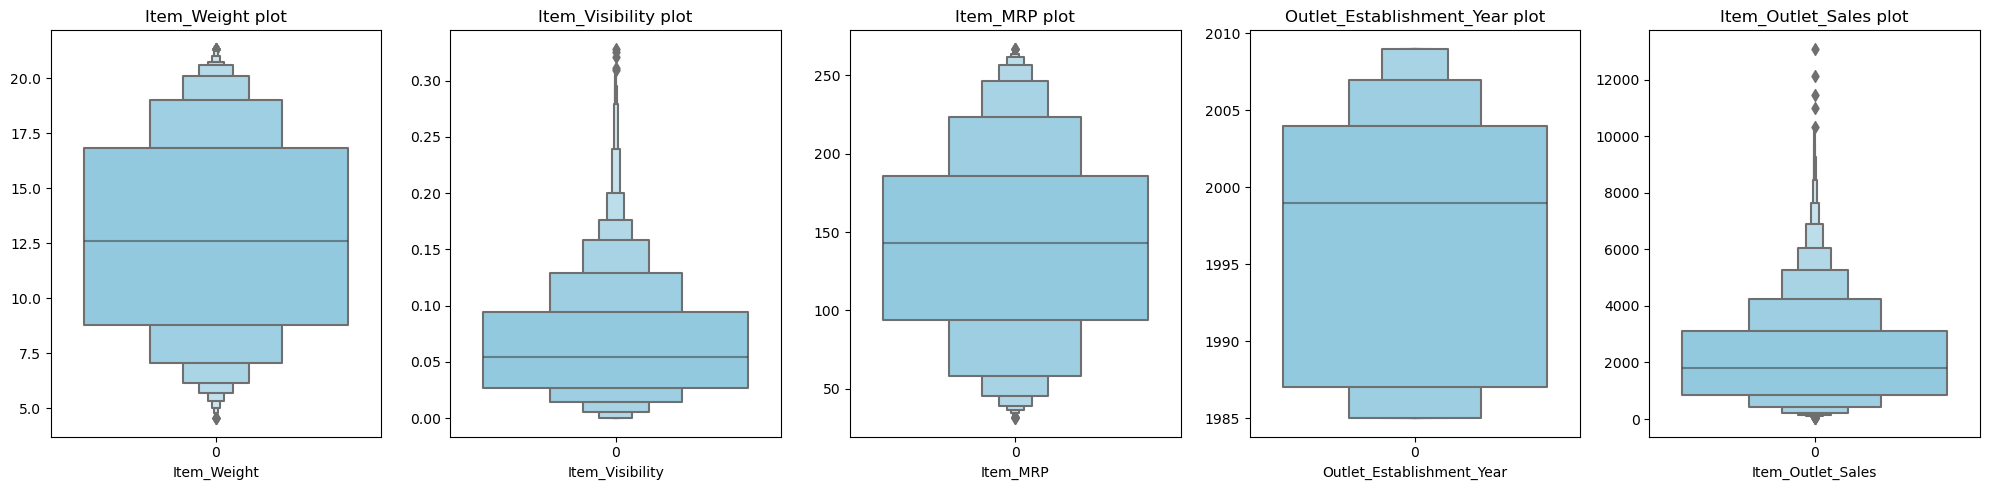

In [201]:
# 1. Define the number of columns you want to plot
cols_to_plot = num_cols.columns
n_cols = len(cols_to_plot)

# 2. Create a figure and a set of subplots (1 row, 5 columns)
# figsize control the width and height of the entire row
fig, axes = plt.subplots(1, n_cols, figsize=(20, 5)) 

# 3. Loop through columns and their corresponding index (i)
for i, col_name in enumerate(cols_to_plot):
    # Use the 'ax' parameter to tell seaborn which subplot to use
    sns.boxenplot(data=num_cols[col_name], ax=axes[i], color='skyblue')
    
    # Set title for each individual subplot
    axes[i].set_title(f"{col_name} plot")
    
    # Optional: Clean up labels
    axes[i].set_xlabel(col_name)

# 4. Adjust layout so titles and labels don't overlap
plt.tight_layout()
plt.show()

In [202]:
num_cols["Item_Weight"].fillna(num_cols["Item_Weight"].mean(),inplace=True)

In [203]:
num_cols.isnull().sum()

Item_Weight                  0
Item_Visibility              0
Item_MRP                     0
Outlet_Establishment_Year    0
Item_Outlet_Sales            0
dtype: int64

In [127]:
# now concat num and cats_col 
new_df=pd.concat([num_cols,cat_cols],axis=1)
new_df.head(2)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,9.30,0.016047,249.8092,1999,3735.1380,FDA15,Low Fat,Dairy,OUT049,Medium,Tier 1,Supermarket Type1
1,5.92,0.019278,48.2692,2009,443.4228,DRC01,Regular,Soft Drinks,OUT018,Medium,Tier 3,Supermarket Type2


In [128]:
new_df.shape

(8523, 12)

In [206]:
# 1. Replace 0 with NaN so we can use fillna or transform
df['Item_Visibility'] = df['Item_Visibility'].replace(0, np.nan)

# 2. Fill NaN values with the mean of that specific Item_Identifier
df['Item_Visibility'] = df['Item_Visibility'].fillna(
    df.groupby('Item_Identifier')['Item_Visibility'].transform('mean')
)

# 3. If any items still have NaN (because they only appeared once with 0 visibility), 
# fill them with the global mean
df['Item_Visibility'] = df['Item_Visibility'].fillna(df['Item_Visibility'].mean())

In [207]:
new_df[new_df['Item_Visibility']==0]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type


In [208]:
# Get duumies as not working on numerical data 
df1=pd.get_dummies(data=new_df,columns =["Item_Fat_Content","Item_Type","Outlet_Size"
                                    ,"Outlet_Location_Type","Outlet_Type"],dtype="int",drop_first=True)

In [209]:
df1.shape

(8523, 30)

In [210]:
df1.columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Outlet_Sales', 'Item_Identifier',
       'Outlet_Identifier', 'Item_Fat_Content_Regular', 'Item_Type_Breads',
       'Item_Type_Breakfast', 'Item_Type_Canned', 'Item_Type_Dairy',
       'Item_Type_Frozen Foods', 'Item_Type_Fruits and Vegetables',
       'Item_Type_Hard Drinks', 'Item_Type_Health and Hygiene',
       'Item_Type_Household', 'Item_Type_Meat', 'Item_Type_Others',
       'Item_Type_Seafood', 'Item_Type_Snack Foods', 'Item_Type_Soft Drinks',
       'Item_Type_Starchy Foods', 'Outlet_Size_Medium', 'Outlet_Size_Small',
       'Outlet_Location_Type_Tier 2', 'Outlet_Location_Type_Tier 3',
       'Outlet_Type_Supermarket Type1', 'Outlet_Type_Supermarket Type2',
       'Outlet_Type_Supermarket Type3'],
      dtype='object')

In [211]:
target=["Item_Outlet_Sales"]
Features=df1.drop(columns=["Item_Identifier","Outlet_Identifier","Item_Outlet_Sales"]).columns

In [212]:
len(Features)

27

In [213]:
y=df1[target]
x=df1[Features]

In [214]:
x.shape

(8523, 27)

In [215]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=.3, random_state=90)

### Linear Regression

In [216]:
base_model=LinearRegression()

In [217]:
base_model.fit(x_train, y_train)

LinearRegression()

In [218]:
base_model.score(x_train,y_train)

0.5683773555349416

In [219]:
base_model.score(x_test,y_test)

0.5484368399051711

In [220]:
# 1. First, make predictions using your trained model
y_pred = base_model.predict(x_test)

# 2. Calculate Mean Squared Error (MSE)
mse=mean_squared_error(y_test,y_pred)

# 3.calculate Rmse 
rmse=np.sqrt(mse)
rmse

1146.7252005982127

In [221]:
# Linear regression model --> 1187 score , 4397 rank 

### Improvement

### Decision Tree Regressor 

In [222]:
from sklearn.tree import DecisionTreeRegressor

In [223]:
dt=DecisionTreeRegressor(max_depth=8)

In [224]:
dt.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=8)

In [225]:
dt.score(x_train,y_train)

0.6646276595263348

In [226]:
dt.score(x_test,y_test)

0.513482188403243

In [227]:
pred_data=dt.predict(x_test)
mse=mean_squared_error(y_test,pred_data)
np.sqrt(mse)

1190.280934305811

In [228]:
# Decision Tree Regressor model --> 1187 score , 4397 rank 

### Decision Tree GridSearchCv

In [229]:
from sklearn.model_selection import GridSearchCV
params={
    "criterion":["squared_error", "friedman_mse"],
    "max_depth":[4,6,8,10,12],
    "min_samples_split":[10,20,40],
    "min_samples_leaf":[5,10,20]
}
dt = DecisionTreeRegressor(random_state=1999)
gdt=GridSearchCV(estimator=dt,  param_grid=params, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
gdt.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=1999),
             n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse'],
                         'max_depth': [4, 6, 8, 10, 12],
                         'min_samples_leaf': [5, 10, 20],
                         'min_samples_split': [10, 20, 40]},
             scoring='neg_mean_squared_error')

In [230]:
np.sqrt(abs(gdt.best_score_))

1092.1936268475047

In [231]:
gdt.best_params_

{'criterion': 'squared_error',
 'max_depth': 6,
 'min_samples_leaf': 20,
 'min_samples_split': 10}

In [232]:
gdt_best=gdt.best_estimator_
gdt_best

DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, min_samples_split=10,
                      random_state=1999)

In [233]:
y_pred_gdt=gdt_best.predict(x_test)
rmse=np.sqrt(mean_squared_error(y_test,y_pred_gdt))
rmse

1098.9831413612785

In [155]:
# GridSearchCV gives 1172 score and rank 3680

### Bagging

In [156]:
from sklearn.ensemble import BaggingRegressor
bagdt=BaggingRegressor(estimator=gdt_best, n_estimators=50,max_samples=.8,bootstrap=True,random_state=42,n_jobs=-1)

In [157]:
bagdt.fit(x_train,y_train)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:509: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=6,
                                                 min_samples_leaf=20,
                                                 min_samples_split=10,
                                                 random_state=1999),
                 max_samples=0.8, n_estimators=50, n_jobs=-1, random_state=42)

In [158]:
bagdt.estimator_

DecisionTreeRegressor(max_depth=6, min_samples_leaf=20, min_samples_split=10,
                      random_state=1999)

In [159]:
bagdt.score(x_train,y_train)

0.6250773836922241

In [160]:
bagdt.score(x_test,y_test)

0.5943346167463931

In [161]:
bagdt_pred=bagdt.predict(x_test)
rmse=np.sqrt(mean_squared_error(y_test,bagdt_pred))
rmse

1086.8862126418671

In [162]:
# Bagging regressor gives 1157 score and rank 2770

### Bagging GridSearchCv

In [163]:
bag_params={
    'n_estimators': [10, 30, 50, 100],
    'max_samples': [0.5, 0.7, 0.8, 1.0],
    'max_features': [0.5, 0.8, 1.0],
    'bootstrap': [True, False]
}
bagr=BaggingRegressor(estimator=gdt_best, random_state=1999)
gbag=GridSearchCV(estimator=bagr, param_grid=bag_params, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
gbag.fit(x_train, y_train)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\ensemble\_bagging.py:509: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


GridSearchCV(cv=5,
             estimator=BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=6,
                                                                        min_samples_leaf=20,
                                                                        min_samples_split=10,
                                                                        random_state=1999),
                                        random_state=1999),
             n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'max_features': [0.5, 0.8, 1.0],
                         'max_samples': [0.5, 0.7, 0.8, 1.0],
                         'n_estimators': [10, 30, 50, 100]},
             scoring='neg_mean_squared_error')

In [164]:
gbag.best_params_

{'bootstrap': True,
 'max_features': 1.0,
 'max_samples': 0.7,
 'n_estimators': 100}

In [165]:
np.sqrt(abs(gbag.best_score_))

1077.5135422958742

In [166]:
gbag_pred=gbag.predict(x_test)
rmse=np.sqrt(mean_squared_error(y_test,gbag_pred))
rmse

1085.620193846404

In [167]:
# gridsearchcv Bagging regressor gives 1155 score and rank 2605

### Random Forest classifier 

In [168]:
from sklearn.ensemble import RandomForestRegressor

In [169]:
rf=RandomForestRegressor()
rf.fit(x_train,y_train)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

In [170]:
rf.score(x_train,y_train)

0.9370789852979795

In [171]:
rf.score(x_test,y_test)

0.528715179779149

In [172]:
# means random forest overfitting , depth is unlimited and it learns more on training data 

In [173]:
# find rmse 
rf_pred=rf.predict(x_test)
rmse=np.sqrt(mean_squared_error(y_test,rf_pred))
rmse

1171.498753242214

In [174]:
rf_controlled = RandomForestRegressor(
    n_estimators=200, 
    max_depth=6,              # Depth ko restrict karein
    min_samples_leaf=50,      # Leaf size bada rakhein taaki noise kam ho
    max_features='sqrt',      # Har split par kam features dekhega
    random_state=1999,
    n_jobs=-1
)
rf_controlled.fit(x_train,y_train)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor(max_depth=6, max_features='sqrt', min_samples_leaf=50,
                      n_estimators=200, n_jobs=-1, random_state=1999)

In [175]:
rf_controlled.score(x_train,y_train)

0.4762644582177099

In [176]:
rf_controlled.score(x_test,y_test)

0.4688846523571303

In [177]:
rf_con_pred=rf_controlled.predict(x_test)
rmse=np.sqrt(mean_squared_error(y_test,rf_con_pred))
rmse

1243.6395662607422

### Gridsearch RandomForest Regressor 

In [76]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Narrowed down to the most impactful 'levers' for BigMart
rf_params = {
    "n_estimators": [100, 200],               # 100 is usually enough for a baseline
    "max_depth": [6, 10, 15],                 # Prevents overfitting on smallish datasets
    "min_samples_leaf": [5, 20],              # Helps generalize across different store types
    "max_features": ["sqrt", 0.3, 0.6],       # 0.3-0.6 is often better than 'None' (all)
    "max_samples": [0.7, 0.8]                 # Provides enough data for each tree to be stable
}

rf = RandomForestRegressor(random_state=1999, n_jobs=-1)

# Using verbose=2 so you can actually see the progress in the console
grf = GridSearchCV(
    estimator=rf, 
    param_grid=rf_params, 
    cv=5, 
    scoring="neg_root_mean_squared_error", # Changed to RMSE directly
    n_jobs=-1,
    verbose=2
)

grf.fit(x_train, y_train)


Fitting 5 folds for each of 72 candidates, totalling 360 fits


C:\Users\hp\anaconda3\Lib\site-packages\sklearn\base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best Parameters: {'max_depth': 10, 'max_features': 0.6, 'max_samples': 0.7, 'min_samples_leaf': 20, 'n_estimators': 200}
Best RMSE: 1080.889699018026


In [77]:
grf.score(x_train,y_train)

-1022.2063481162463

In [94]:
print("Best Parameters:", grf.best_params_)

Best Parameters: {'max_depth': 10, 'max_features': 0.6, 'max_samples': 0.7, 'min_samples_leaf': 20, 'n_estimators': 200}


In [95]:
print("Best RMSE:", grf.best_score_)

Best RMSE: -1080.889699018026


In [96]:
grf_pred=grf.predict(x_test)
rmse=np.sqrt(mean_squared_error(y_test,grf_pred))
rmse

1093.104390428833

## Test

In [79]:
test0=pd.read_csv(r"D:\Imarticus pg Diploma\Ml-Bigmart sales prediction\test_AbJTz2l.csv")

In [80]:
test0.shape

(5681, 11)

In [81]:
num_cols=test0.select_dtypes(exclude="object")
cat_cols=test0.select_dtypes(include="object")

# for cat_cols
cat_cols["Item_Fat_Content"].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'},inplace=True)
cat_cols["Outlet_Size"].fillna(cat_cols["Outlet_Size"].mode()[0],inplace=True)

# for num_cols
num_cols["Item_Weight"].fillna(num_cols["Item_Weight"].mean(),inplace=True)

# now concat num and cats_col 
test1=pd.concat([num_cols,cat_cols],axis=1)

# Get dummies as not working on numerical data 
test1=pd.get_dummies(data=test1,columns =["Item_Fat_Content","Item_Type","Outlet_Size"
                                    ,"Outlet_Location_Type","Outlet_Type"],dtype="int",drop_first=True)


In [82]:
test1.shape

(5681, 29)

In [83]:
test1.columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year', 'Item_Identifier', 'Outlet_Identifier',
       'Item_Fat_Content_Regular', 'Item_Type_Breads', 'Item_Type_Breakfast',
       'Item_Type_Canned', 'Item_Type_Dairy', 'Item_Type_Frozen Foods',
       'Item_Type_Fruits and Vegetables', 'Item_Type_Hard Drinks',
       'Item_Type_Health and Hygiene', 'Item_Type_Household', 'Item_Type_Meat',
       'Item_Type_Others', 'Item_Type_Seafood', 'Item_Type_Snack Foods',
       'Item_Type_Soft Drinks', 'Item_Type_Starchy Foods',
       'Outlet_Size_Medium', 'Outlet_Size_Small',
       'Outlet_Location_Type_Tier 2', 'Outlet_Location_Type_Tier 3',
       'Outlet_Type_Supermarket Type1', 'Outlet_Type_Supermarket Type2',
       'Outlet_Type_Supermarket Type3'],
      dtype='object')

In [84]:
features=test1.drop(columns=["Item_Identifier","Outlet_Identifier"]).columns

In [85]:
test_data=test1[features]
test_data.shape

(5681, 27)

In [86]:
prd_data=gbag.predict(test_data)

In [87]:
test0["Item_Outlet_Sales"]=pd.DataFrame(prd_data)

In [88]:
test0.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1,1719.811765
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1,1367.473620
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store,593.770627
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1,2411.527070
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3,5947.936693


In [89]:
# test0["Item_Outlet_Sales"]=np.where(test0["Item_Outlet_Sales"]<0,0,test0["Item_Outlet_Sales"])

In [90]:
a=test0[["Item_Identifier","Outlet_Identifier","Item_Outlet_Sales"]]

In [91]:
a.head()

,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1719.811765
1,FDW14,OUT017,1367.473620
2,NCN55,OUT010,593.770627
3,FDQ58,OUT017,2411.527070
4,FDY38,OUT027,5947.936693


In [92]:
a.to_csv(r"D:\Imarticus pg Diploma\Ml-Bigmart sales prediction\gbag_model.csv",index=False)

In [93]:
a[a["Item_Outlet_Sales"]<0]

,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
